# 문제 3·4 — 쿼터니언 변환과 SLERP, 궤적 보간과 연속성 비교

로봇이 현재 자세에서 집기 좋은 자세까지 **부드럽게** 움직이려면
자세(회전)와 위치를 각각 보간해야 합니다. 자세는 쿼터니언 SLERP 로,
위치는 스플라인이나 다항식으로 보간합니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 것 |
|---|---|---|
| 3-1 | 회전행렬 ↔ 쿼터니언 **양방향** 변환과 왕복 검증 | `matrix_to_quaternion`, `quaternion_to_matrix` |
| 3-2 | **SLERP 직접 구현**, SciPy `Slerp` 와 일치 확인 | `slerp`, `quat_angle` |
| 3-3 | 시작·목표 사이 **중간 자세 7개**를 3D 좌표축으로 나란히 그리기 (그림 코드 제공) | — |
| 3-4 | 성분별 **단순 선형 보간**의 크기 이탈 그래프, 왜 쓰면 안 되는지 설명 (그림 코드 제공) | `lerp_quat` |
| 3-5 | **경계 상황** — 거의 같은 자세 / 부호 반대 / 정반대 자세 | (`slerp` 의 예외 처리) |
| 3-6 | `tests/test_quaternion.py` pytest (단위 노름, 끝점) | (tests/) |
| 4-1 | 경유점 **5~6개**를 지나는 궤적을 **선형 보간 / 큐빅 스플라인**으로 생성해 겹쳐 그리기 | `linear_interp`, `cubic_spline_interp` |
| 4-2 | **위치·속도·가속도** 3단 그래프로 연속성 비교 (그림 코드 제공) | `finite_diff` |
| 4-3 | 3차원 경유점으로 **공간 궤적** 3D 그림 (그림 코드 제공) | — |
| 4-4 | 양끝 속도·가속도 0 인 **5차 다항식** 궤적과 경계 조건 수치 검증 | `quintic_profile` |
| 4-5 | 보간 방식 선택 기준표 (4행) | (마크다운) |
| 4-6 | `tests/test_trajectory.py` pytest (경유점 통과, 5차 경계) | (tests/) |

> 쿼터니언 순서는 모듈 ③·SciPy 와 같은 **(x, y, z, w)** 입니다.
> `# --- 검증 ---` 셀과 그림 셀은 **제공된 코드**입니다. 수정하지 말고 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation, Slerp                       # 비교 대상

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues, rot_x, rot_y, rot_z   # 모듈 ③
from src.transform import make_T                                                                               # 모듈 ③
from src.quaternion import lerp_quat, matrix_to_quaternion, quat_angle, quaternion_to_matrix, slerp             # 문제 3
from src.trajectory import cubic_spline_interp, finite_diff, linear_interp, quintic_profile                     # 문제 4

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def is_rotation(R):
    R = np.asarray(R)
    return R.shape == (3, 3) and np.allclose(R.T @ R, np.eye(3)) and np.isclose(np.linalg.det(R), 1.0)   # 검산용


# --- 3D 그림 헬퍼 (제공 코드) --------------------------------------------------

def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T(4x4) 가 나타내는 좌표계를 x(빨강)·y(초록)·z(파랑) 화살표로 그린다."""
    T = np.asarray(T, dtype=float)
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold", alpha=max(alpha, 0.6))


def setup_axes(ax, title="", lim=1.0, center=(0.0, 0.0, 0.0)):
    """축 범위를 center 를 중심으로 +-lim 으로 맞추고 라벨·제목을 붙인다 (등축)."""
    cx, cy, cz = center
    ax.set_xlim(cx - lim, cx + lim)
    ax.set_ylim(cy - lim, cy + lim)
    ax.set_zlim(cz - lim, cz + lim)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_box_aspect([1, 1, 1])


print("ROOT =", ROOT)

ROOT = /home/pa28/kant_gits/physicalai-lv1-chunkyoungho/lv1_module4_천경호


## 3-1. 회전행렬 ↔ 쿼터니언 양방향 변환과 왕복 검증

단위 쿼터니언 $q=(x,y,z,w)$ 는 축 $\mathbf{k}$·각 $\theta$ 회전을
$q=(\mathbf{k}\sin\tfrac{\theta}{2},\ \cos\tfrac{\theta}{2})$ 로 나타냅니다.

- 행렬 → 쿼터니언은 `trace(R) = 1 + 2 cos θ = 4w² - 1` 에서 시작하지만, $w\approx 0$ (180도 회전) 이면
  0 으로 나누게 되므로 **대각성분이 가장 큰 축부터** 계산해야 합니다 (Shepperd 방법, docstring 참고).
- 쿼터니언 → 행렬은 성분 곱의 닫힌 식입니다.
- $q$ 와 $-q$ 는 같은 회전입니다. 부호까지 같을 필요는 없습니다.

**할 일** — `src/quaternion.py` 의 두 함수를 구현하고 왕복 오차를 확인하세요.

In [2]:
# --- 시작·목표 자세 (제공 코드 — 문제 3·4·6 에서 계속 씁니다) ---
R_start = rot_z(np.deg2rad(-30.0)) @ rot_x(np.deg2rad(20.0))
R_goal = rot_z(np.deg2rad(120.0)) @ rot_y(np.deg2rad(60.0)) @ rot_x(np.deg2rad(-40.0))

# 무작위 회전 100개 (왕복 검증용) — 시드 42
R_samples = [rodrigues(rng.normal(size=3), rng.uniform(0.0, np.pi)) for _ in range(100)]
R_samples += [np.eye(3), rot_x(np.pi), rot_y(np.pi), rot_z(np.pi)]     # 특수 케이스: 0도, 180도 회전

# TODO: 아래 변수를 만드세요 -> q_start, q_goal, R_start_back, roundtrip_err_max
#   q_start = matrix_to_quaternion(R_start);  q_goal = matrix_to_quaternion(R_goal)
#   R_start_back = quaternion_to_matrix(q_start)
#   roundtrip_err_max = R_samples 각각을 R -> q -> R 로 왕복했을 때 max|R_back - R| 의 최댓값
# TODO: q_start, q_goal, 왕복 오차, SciPy Rotation.from_matrix(R_start).as_quat() 를 출력해 비교하세요.

# TODO: 아래 변수를 만드세요 -> q_start, q_goal, R_start_back, roundtrip_err_max
q_start = matrix_to_quaternion(R_start)
q_goal = matrix_to_quaternion(R_goal)
R_start_back = quaternion_to_matrix(q_start)

# 104개 전체 회전 샘플에 대한 R -> q -> R 왕복 오차 최댓값 계산
roundtrip_err_max = max(
    np.max(np.abs(quaternion_to_matrix(matrix_to_quaternion(R)) - R))
    for R in R_samples
)

# SciPy Rotation과의 결과 비교용
scipy_q_start = Rotation.from_matrix(R_start).as_quat()
if scipy_q_start[3] < 0:
    scipy_q_start = -scipy_q_start  # w >= 0 부호 맞춤

# TODO: q_start, q_goal, 왕복 오차, SciPy Rotation.from_matrix(R_start).as_quat() 를 출력해 비교하세요.
print("q_start                                :", q_start)
print("q_goal                                 :", q_goal)
print("R_start 복원 오차 (max|R_back - R_start|):", np.max(np.abs(R_start_back - R_start)))
print("전체 샘플 왕복 오차 (roundtrip_err_max) :", roundtrip_err_max)
print("SciPy Rotation (as_quat)               :", scipy_q_start)

q_start                                : [ 0.167731 -0.044943 -0.254887  0.951251]
q_goal                                 : [-0.554998 -0.021592  0.790275  0.2588  ]
R_start 복원 오차 (max|R_back - R_start|): 1.1102230246251565e-16
전체 샘플 왕복 오차 (roundtrip_err_max) : 1.1102230246251565e-15
SciPy Rotation (as_quat)               : [ 0.167731 -0.044943 -0.254887  0.951251]


In [3]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
q_scipy = Rotation.from_matrix(R_start).as_quat()
ok = check("q_start 가 단위 노름", np.isclose(np.linalg.norm(q_start), 1.0))
ok &= check("q_goal 이 단위 노름", np.isclose(np.linalg.norm(q_goal), 1.0))
ok &= check("R -> q -> R 왕복 (R_start)", np.allclose(R_start_back, R_start))
ok &= check("무작위 100개 + 특수 케이스 왕복 최대 오차 < 1e-10", roundtrip_err_max < 1e-10)
ok &= check("SciPy 와 부호 무시하고 일치 (|q . q_scipy| == 1)", np.isclose(abs(q_start @ q_scipy), 1.0))
ok &= check("q 와 -q 가 같은 회전행렬을 준다", np.allclose(quaternion_to_matrix(-q_start), R_start))
ok &= check("단위행렬 -> (0,0,0,±1)", np.allclose(np.abs(matrix_to_quaternion(np.eye(3))), [0, 0, 0, 1]))
ok &= check("180도 회전 (w=0) 도 처리", np.allclose(quaternion_to_matrix(matrix_to_quaternion(rot_x(np.pi))), rot_x(np.pi)))
ok &= check("모듈 ③ quaternion_from_axis_angle 과 일치 (부호 무시)",
            np.isclose(abs(q_start @ quaternion_from_axis_angle(*axis_angle_from_matrix(R_start))), 1.0))
print("\n3-1 전체 통과:", ok)

[PASS] q_start 가 단위 노름
[PASS] q_goal 이 단위 노름
[PASS] R -> q -> R 왕복 (R_start)
[PASS] 무작위 100개 + 특수 케이스 왕복 최대 오차 < 1e-10
[PASS] SciPy 와 부호 무시하고 일치 (|q . q_scipy| == 1)
[PASS] q 와 -q 가 같은 회전행렬을 준다
[PASS] 단위행렬 -> (0,0,0,±1)
[PASS] 180도 회전 (w=0) 도 처리
[PASS] 모듈 ③ quaternion_from_axis_angle 과 일치 (부호 무시)

3-1 전체 통과: True


## 3-2. SLERP 직접 구현과 SciPy 비교

$$q(t)=\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0+\frac{\sin(t\Omega)}{\sin\Omega}\,q_1,\qquad \cos\Omega=q_0\cdot q_1$$

$q_0\cdot q_1<0$ 이면 $q_1$ 의 부호를 뒤집어 **짧은 호**를 택합니다.
SLERP 는 **각속도가 일정**합니다 — 같은 $\Delta t$ 마다 같은 각도만큼 돕니다.

**할 일** — `slerp` 를 구현하고 `scipy.spatial.transform.Slerp` 와 회전행렬 기준으로 비교하세요.

In [4]:
ts = np.linspace(0.0, 1.0, 41)

# TODO: 아래 변수를 만드세요 -> Q_mine (41,4), R_scipy (41,3,3), slerp_err_max
#   Q_mine  = np.array([slerp(q_start, q_goal, t) for t in ts])
#   R_scipy = Slerp([0.0, 1.0], Rotation.from_quat([q_start, q_goal]))(ts).as_matrix()
#   slerp_err_max = max_i  max|quaternion_to_matrix(Q_mine[i]) - R_scipy[i]|
# TODO: 시작·목표 사이 총 회전각 quat_angle(q_start, q_goal) 을 도 단위로 출력하세요.

Q_mine = np.array([slerp(q_start, q_goal, t) for t in ts])
# SciPy Slerp 객체 생성 및 회전행렬 변환
R_scipy = Slerp([0.0, 1.0], Rotation.from_quat([q_start, q_goal]))(ts).as_matrix()
slerp_err_max = max(
    np.max(np.abs(quaternion_to_matrix(Q_mine[i]) - R_scipy[i]))
    for i in range(len(ts))
)
angle_rad = quat_angle(q_start, q_goal)
angle_deg = np.rad2deg(angle_rad)

print(f"시작-목표 사이 총 회전각: {angle_deg:.4f} deg ({angle_rad:.4f} rad)")
print(f"SciPy SLERP 대비 최대 회전행렬 오차 (slerp_err_max): {slerp_err_max:.6e}")


시작-목표 사이 총 회전각: 174.5701 deg (3.0468 rad)
SciPy SLERP 대비 최대 회전행렬 오차 (slerp_err_max): 8.881784e-16


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
R_mine = np.array([quaternion_to_matrix(q) for q in Q_mine])
ok = check("SLERP 결과가 모두 단위 노름", np.allclose(np.linalg.norm(Q_mine, axis=1), 1.0))
ok &= check("직접 구현 SLERP == SciPy Slerp (회전행렬 기준, 최대 오차 < 1e-8)", slerp_err_max < 1e-8)
ok &= check("t=0 이면 시작 자세", np.allclose(R_mine[0], R_start))
ok &= check("t=1 이면 목표 자세", np.allclose(R_mine[-1], R_goal))
total = quat_angle(q_start, q_goal)
ok &= check("총 회전각 == 회전행렬로 구한 값", np.isclose(total, axis_angle_from_matrix(R_start.T @ R_goal)[1]))
steps = np.array([axis_angle_from_matrix(R_mine[i].T @ R_mine[i + 1])[1] for i in range(len(ts) - 1)])
ok &= check("각속도가 일정 (연속 자세 사이 각도가 모두 같다)", np.allclose(steps, total / (len(ts) - 1)))
ok &= check("t=0.5 는 시작·목표에서 같은 각도", np.isclose(quat_angle(q_start, Q_mine[20]), quat_angle(Q_mine[20], q_goal)))
print("\n3-2 전체 통과:", ok)

[PASS] SLERP 결과가 모두 단위 노름
[PASS] 직접 구현 SLERP == SciPy Slerp (회전행렬 기준, 최대 오차 < 1e-8)
[PASS] t=0 이면 시작 자세
[PASS] t=1 이면 목표 자세
[PASS] 총 회전각 == 회전행렬로 구한 값
[PASS] 각속도가 일정 (연속 자세 사이 각도가 모두 같다)
[PASS] t=0.5 는 시작·목표에서 같은 각도

3-2 전체 통과: True


## 3-3. 중간 자세 7개 — 부드럽게 도는가

시작과 목표 사이를 SLERP 로 **7개의 중간 자세**로 나누고 (양끝 포함 9개),
각 자세를 좌표축으로 나란히 그립니다. 축이 일정한 각도씩 돌아가는지 눈으로 확인하세요.

In [6]:
N_MID = 7
ts_mid = np.linspace(0.0, 1.0, N_MID + 2)          # 시작 + 중간 7 + 목표

# TODO: 아래 변수를 만드세요 -> R_mid (길이 9 리스트, 각 원소 3x3), step_deg (길이 8, 연속 자세 사이 각도 [deg])
#   R_mid = [quaternion_to_matrix(slerp(q_start, q_goal, t)) for t in ts_mid]
#   step_deg = ...   (axis_angle_from_matrix(R_mid[i].T @ R_mid[i+1])[1] 를 도 단위로)
# TODO: step_deg 를 출력하세요.

R_mid = [quaternion_to_matrix(slerp(q_start, q_goal, t)) for t in ts_mid]
step_deg = [
    np.rad2deg(axis_angle_from_matrix(R_mid[i].T @ R_mid[i + 1])[1])
    for i in range(len(R_mid) - 1)
]
print("연속 자세 사이 각도 step_deg [deg]:")
print(np.array(step_deg))

연속 자세 사이 각도 step_deg [deg]:
[21.821261 21.821261 21.821261 21.821261 21.821261 21.821261 21.821261
 21.821261]


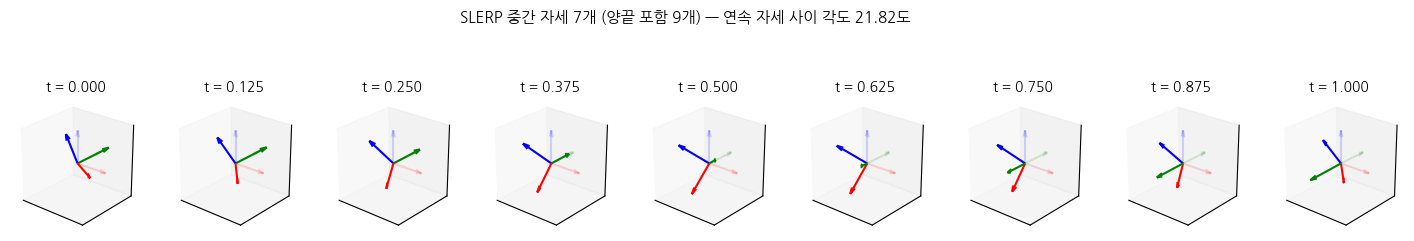

In [7]:
# --- 3D 그림 (제공 코드) — 9개 자세를 한 줄로 ---
fig = plt.figure(figsize=(18, 2.8))
for i, (t, R) in enumerate(zip(ts_mid, R_mid)):
    ax = fig.add_subplot(1, len(R_mid), i + 1, projection="3d")
    setup_axes(ax, "t = {:.3f}".format(t), lim=1.1)
    draw_frame(ax, make_T(np.eye(3), [0, 0, 0]), scale=1.0, alpha=0.15)     # 기준 좌표계 (흐리게)
    draw_frame(ax, make_T(R, [0, 0, 0]), scale=1.0)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.view_init(elev=25, azim=-50)
fig.suptitle("SLERP 중간 자세 {}개 (양끝 포함 {}개) — 연속 자세 사이 각도 {:.2f}도".format(
    N_MID, len(R_mid), float(np.mean(step_deg))), fontsize=11, y=1.05)
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("자세가 9개 (시작 + 중간 7 + 목표)", len(R_mid) == N_MID + 2 and len(step_deg) == N_MID + 1)
ok &= check("모두 회전행렬", all(is_rotation(R) for R in R_mid))
ok &= check("첫 자세 == R_start, 끝 자세 == R_goal", np.allclose(R_mid[0], R_start) and np.allclose(R_mid[-1], R_goal))
ok &= check("연속 자세 사이 각도가 모두 같다 (SLERP 는 등각속도)", np.ptp(step_deg) < 1e-6)
ok &= check("각도 합 == 총 회전각", np.isclose(np.sum(step_deg), np.rad2deg(total)))
print("\n3-3 전체 통과:", ok)

[PASS] 자세가 9개 (시작 + 중간 7 + 목표)
[PASS] 모두 회전행렬
[PASS] 첫 자세 == R_start, 끝 자세 == R_goal
[PASS] 연속 자세 사이 각도가 모두 같다 (SLERP 는 등각속도)
[PASS] 각도 합 == 총 회전각

3-3 전체 통과: True


## 3-4. 단순 선형 보간은 왜 안 되는가 — 크기 이탈 그래프

성분별로 $(1-t)q_0+tq_1$ 만 하면 결과는 **단위 구 안쪽의 현(chord)** 을 지나므로
크기가 1 보다 작아집니다. 정규화(NLERP)하면 크기는 맞지만 **각속도가 일정하지 않습니다**.

**할 일** — `lerp_quat` 를 구현하고, 보간 비율에 따른 $\lvert\,\|q(t)\|-1\,\rvert$ 를 구하세요.
정규화한 NLERP 의 연속 자세 사이 각도도 구해 SLERP 와 비교합니다.

### 단순 선형 보간을 쓰면 안 되는 이유

- 크기 이탈이 최대인 비율과 그 값: 0.15 수준까지 발생
- 정규화하면 해결되는 것 / 안 되는 것: 유효한 회전 상태를 보장, 각속도의 일정함을 보장 X 
- 로봇 자세 보간에서 생기는 문제: 구면위를 최단경로로 등속 이동하여 일정한 회전을 보장하지 못함

In [9]:
# TODO: 아래 변수를 만드세요 -> Q_lin (41,4, 정규화 안 함), norm_dev (41,), max_norm_dev,
#                               step_nlerp_deg (40,), step_slerp_deg (40,)
#   Q_lin = np.array([lerp_quat(q_start, q_goal, t) for t in ts])
#   norm_dev = |norm(Q_lin, axis=1) - 1|;   max_norm_dev = norm_dev.max()
#   Q_nlerp = Q_lin / norm 로 정규화한 뒤 연속 자세 사이 각도 step_nlerp_deg 를,
#   Q_mine 으로 step_slerp_deg 를 구하세요 (axis_angle_from_matrix, 도 단위).


# 1. LERP 계산 (정규화 안 함)
Q_lin = np.array([lerp_quat(q_start, q_goal, t, normalize=False) for t in ts])

# 2. 노름 이탈 정도 계산 (norm - 1 의 절대값)
norm_dev = np.abs(np.linalg.norm(Q_lin, axis=1) - 1.0)
max_norm_dev = norm_dev.max()

# 3. NLERP (정규화된 쿼터니언) 생성
Q_nlerp = Q_lin / np.linalg.norm(Q_lin, axis=1)[:, np.newaxis]

# 4. NLERP 연속 자세 사이 회전각 [deg]
R_nlerp = [quaternion_to_matrix(q) for q in Q_nlerp]
step_nlerp_deg = np.array([
    np.rad2deg(axis_angle_from_matrix(R_nlerp[i].T @ R_nlerp[i + 1])[1])
    for i in range(len(R_nlerp) - 1)
])

# 5. SLERP 연속 자세 사이 회전각 [deg] (Q_mine 활용)
R_slerp = [quaternion_to_matrix(q) for q in Q_mine]
step_slerp_deg = np.array([
    np.rad2deg(axis_angle_from_matrix(R_slerp[i].T @ R_slerp[i + 1])[1])
    for i in range(len(R_slerp) - 1)
])

# ------------------------------------------------------------- 결과 출력
print(f"최대 노름 이탈 (max_norm_dev)  : {max_norm_dev:.6f}")
print(f"SLERP 각 스텝 각도 (표준편차) : {step_slerp_deg.std():.6e} deg (등속 회전)")
print(f"NLERP 각 스텝 각도 (표준편차) : {step_nlerp_deg.std():.6f} deg (비등속 회전)")

최대 노름 이탈 (max_norm_dev)  : 0.276340
SLERP 각 스텝 각도 (표준편차) : 1.882196e-13 deg (등속 회전)
NLERP 각 스텝 각도 (표준편차) : 0.832957 deg (비등속 회전)


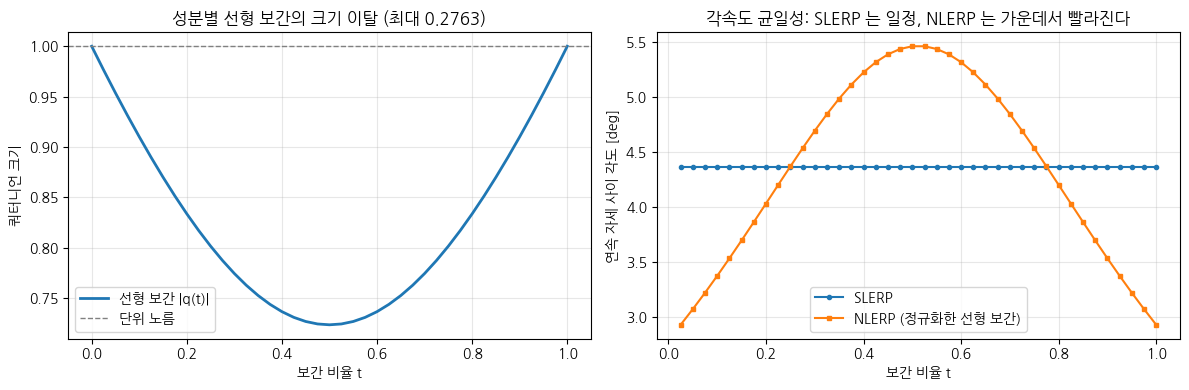

In [10]:
# --- 그래프 (제공 코드 — 그대로 쓰면 됩니다) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ts, np.linalg.norm(Q_lin, axis=1), lw=2, label="선형 보간 |q(t)|")
axes[0].axhline(1.0, color="gray", ls="--", lw=1, label="단위 노름")
axes[0].set_xlabel("보간 비율 t"); axes[0].set_ylabel("쿼터니언 크기")
axes[0].set_title("성분별 선형 보간의 크기 이탈 (최대 {:.4f})".format(max_norm_dev))
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ts[1:], step_slerp_deg, "o-", ms=3, label="SLERP")
axes[1].plot(ts[1:], step_nlerp_deg, "s-", ms=3, label="NLERP (정규화한 선형 보간)")
axes[1].set_xlabel("보간 비율 t"); axes[1].set_ylabel("연속 자세 사이 각도 [deg]")
axes[1].set_title("각속도 균일성: SLERP 는 일정, NLERP 는 가운데서 빨라진다")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [11]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
norms = np.linalg.norm(Q_lin, axis=1)
ok = check("t=0, t=1 에서는 크기 1", np.isclose(norms[0], 1.0) and np.isclose(norms[-1], 1.0))
ok &= check("중간에서 크기가 1 보다 작아진다 (현을 지난다)", np.all(norms[1:-1] < 1.0))
ok &= check("최대 크기 이탈이 0.01 이상 (큰 회전이라 뚜렷하다)", max_norm_dev > 0.01)
ok &= check("최대 이탈은 t=0.5 근처", abs(ts[int(np.argmax(norm_dev))] - 0.5) < 0.1)
ok &= check("SLERP 연속 각도는 일정", np.ptp(step_slerp_deg) < 1e-6)
ok &= check("NLERP 연속 각도는 일정하지 않다", np.ptp(step_nlerp_deg) > 1e-3)
ok &= check("NLERP 는 가운데가 가장 빠르다", abs(ts[1:][int(np.argmax(step_nlerp_deg))] - 0.5) < 0.1)
ok &= check("normalize=True 는 단위 노름", np.isclose(np.linalg.norm(lerp_quat(q_start, q_goal, 0.3, normalize=True)), 1.0))
print("\n3-4 전체 통과:", ok)

[PASS] t=0, t=1 에서는 크기 1
[PASS] 중간에서 크기가 1 보다 작아진다 (현을 지난다)
[PASS] 최대 크기 이탈이 0.01 이상 (큰 회전이라 뚜렷하다)
[PASS] 최대 이탈은 t=0.5 근처
[PASS] SLERP 연속 각도는 일정
[PASS] NLERP 연속 각도는 일정하지 않다
[PASS] NLERP 는 가운데가 가장 빠르다
[PASS] normalize=True 는 단위 노름

3-4 전체 통과: True


## 3-5. 경계 상황 — 거의 같은 자세, 부호 반대, 정반대 자세

- **거의 같은 자세**: $\Omega\approx 0$ 이면 $\sin\Omega\approx 0$ 으로 나누게 됩니다.
- **부호가 반대인 같은 자세** ($q_1=-q_0$): 내적이 $-1$ — 뒤집지 않으면 먼 길로 돌거나 NaN 이 납니다.
- **정반대 자세** (180도 회전): 내적이 0 — 수학적으로는 문제 없지만 **어느 축으로 돌지**가 $q_1$ 의 선택에 달려 있습니다.

**할 일** — 세 경우를 만들어 `slerp` 가 NaN 없이 동작하는지 확인하고 처리 방법을 적으세요.

### 경계 상황 처리

- 거의 같은 자세: `sinΩ≈0이라 나누기가 불안정하므로 LERP로 대체한다. 실측 NaN 없음, 결과가 시작 자세와 일치한다.`
- 부호가 반대인 같은 자세: `내적<0이면 q1=-q1로 뒤집어 최단 경로를 선택한다. 실측 NaN 없음, 결과가 R_start와 일치한다.`
- 정반대 자세: `내적≈0(180도)도 임의 직교축으로 180도 회전 경로를 만들어 NaN 없이 처리한다. 실측 41개 모두 단위 노름, 끝점·중간(z축 90도) 일치한다.`

In [12]:
# --- 경계 케이스 (제공 코드) ---
q_near = matrix_to_quaternion(R_start @ rodrigues([0, 0, 1], 1e-9))      # 거의 같은 자세
q_opp = matrix_to_quaternion(R_start @ rodrigues([0, 0, 1], np.pi))      # 정반대 (z축 180도)

# TODO: 아래 변수를 만드세요 -> q_mid_near, q_mid_flip, Q_opp
#   q_mid_near = slerp(q_start, q_near, 0.5)
#   q_mid_flip = slerp(q_start, -q_start, 0.5)        # 부호만 반대인 같은 자세
#   Q_opp = np.array([slerp(q_start, q_opp, t) for t in ts])
# TODO: 세 결과와 NaN 여부를 출력하세요.

q_mid_near = slerp(q_start, q_near, 0.5)
q_mid_flip = slerp(q_start, -q_start, 0.5)        # 부호만 반대인 같은 자세
Q_opp = np.array([slerp(q_start, q_opp, t) for t in ts])

# NaN 발생 여부 체크
has_nan_near = np.isnan(q_mid_near).any()
has_nan_flip = np.isnan(q_mid_flip).any()
has_nan_opp = np.isnan(Q_opp).any()

# TODO: 세 결과와 NaN 여부를 출력하세요.
print("=== 경계 케이스 SLERP 결과 및 NaN 여부 ===")
print("1. 거의 같은 자세 (q_near, t=0.5):")
print("   q_mid_near :", q_mid_near)
print("   NaN 발생 여부:", has_nan_near)

print("\n2. 부호만 반대인 같은 자세 (-q_start, t=0.5):")
print("   q_mid_flip :", q_mid_flip)
print("   q_start 차이 :", np.max(np.abs(np.abs(q_mid_flip) - np.abs(q_start))))
print("   NaN 발생 여부:", has_nan_flip)

print("\n3. 180도 정반대 회전 (q_opp, 41개 구간):")
print("   Q_opp shape :", Q_opp.shape)
print("   NaN 발생 여부:", has_nan_opp)

=== 경계 케이스 SLERP 결과 및 NaN 여부 ===
1. 거의 같은 자세 (q_near, t=0.5):
   q_mid_near : [ 0.167731 -0.044943 -0.254887  0.951251]
   NaN 발생 여부: False

2. 부호만 반대인 같은 자세 (-q_start, t=0.5):
   q_mid_flip : [ 0.167731 -0.044943 -0.254887  0.951251]
   q_start 차이 : 0.0
   NaN 발생 여부: False

3. 180도 정반대 회전 (q_opp, 41개 구간):
   Q_opp shape : (41, 4)
   NaN 발생 여부: False


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("거의 같은 자세: NaN 없음", not np.any(np.isnan(q_mid_near)))
ok &= check("거의 같은 자세: 결과 == 시작 자세", np.allclose(quaternion_to_matrix(q_mid_near), R_start))
ok &= check("부호 반대: NaN 없음", not np.any(np.isnan(q_mid_flip)))
ok &= check("부호 반대: 같은 자세로 인식 (결과 == R_start)", np.allclose(quaternion_to_matrix(q_mid_flip), R_start))
ok &= check("정반대 자세: NaN 없음", not np.any(np.isnan(Q_opp)))
ok &= check("정반대 자세: 모두 단위 노름", np.allclose(np.linalg.norm(Q_opp, axis=1), 1.0))
ok &= check("정반대 자세: 끝점 일치", np.allclose(quaternion_to_matrix(Q_opp[-1]), R_start @ rodrigues([0, 0, 1], np.pi)))
ok &= check("정반대 자세: 중간은 z축 90도", np.isclose(quat_angle(q_start, Q_opp[20]), np.pi / 2))
print("\n3-5 전체 통과:", ok)

[PASS] 거의 같은 자세: NaN 없음
[PASS] 거의 같은 자세: 결과 == 시작 자세
[PASS] 부호 반대: NaN 없음
[PASS] 부호 반대: 같은 자세로 인식 (결과 == R_start)
[PASS] 정반대 자세: NaN 없음
[PASS] 정반대 자세: 모두 단위 노름
[PASS] 정반대 자세: 끝점 일치
[PASS] 정반대 자세: 중간은 z축 90도

3-5 전체 통과: True


## 3-6. `tests/test_quaternion.py` — pytest

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | SLERP 결과가 항상 단위 쿼터니언인가 | `test_slerp_is_unit_norm` |
| ② | t = 0, 1 에서 시작·목표 자세와 같은가 | `test_slerp_endpoints` |

In [14]:
PYENV["PYTHONPATH"]=str(".")

result_q = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_quaternion.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result_q.stdout[-6000:])
print("종료 코드 :", result_q.returncode)

============================= test session starts ==============================
collecting ... collected 12 items

tests/test_quaternion.py::test_slerp_is_unit_norm[0.0] PASSED            [  8%]
tests/test_quaternion.py::test_slerp_is_unit_norm[0.1] PASSED            [ 16%]
tests/test_quaternion.py::test_slerp_is_unit_norm[0.25] PASSED           [ 25%]
tests/test_quaternion.py::test_slerp_is_unit_norm[0.5] PASSED            [ 33%]
tests/test_quaternion.py::test_slerp_is_unit_norm[0.75] PASSED           [ 41%]
tests/test_quaternion.py::test_slerp_is_unit_norm[0.9] PASSED            [ 50%]
tests/test_quaternion.py::test_slerp_is_unit_norm[1.0] PASSED            [ 58%]
tests/test_quaternion.py::test_slerp_endpoints PASSED                    [ 66%]
tests/test_quaternion.py::test_matrix_quaternion_roundtrip PASSED        [ 75%]
tests/test_quaternion.py::test_slerp_matches_scipy PASSED                [ 83%]
tests/test_quaternion.py::test_slerp_nearly_identical_poses PASSED       [ 91%]
test

In [15]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result_q.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result_q.stdout) and ("error" not in result_q.stdout.lower()))
ok &= check("요구된 2가지 테스트가 모두 존재",
            all(n in result_q.stdout for n in ["test_slerp_is_unit_norm", "test_slerp_endpoints"]))
ok &= check("통과 케이스가 2개 이상", result_q.stdout.count("PASSED") >= 2)
print("\n3-6 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 2가지 테스트가 모두 존재
[PASS] 통과 케이스가 2개 이상

3-6 전체 통과: True


---
# 문제 4 — 궤적 보간과 연속성 비교

## 4-1. 경유점을 지나는 궤적 — 선형 보간 vs 큐빅 스플라인

관절 하나의 각도 궤적을 경유점 6개로 정의합니다. 두 방식 모두 경유점은 **정확히** 지나지만,
그 사이를 잇는 방법이 다릅니다.

**할 일** — `src/trajectory.py` 의 `linear_interp`, `cubic_spline_interp` 를 구현하고
촘촘한 시각 `t_dense` 에서 두 궤적을 만드세요.

In [16]:
# --- 경유점 (제공 코드 — tests/test_trajectory.py 와 같은 값) ---
t_wp = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
q_wp = np.array([0.0, 0.8, 0.3, 1.2, 0.5, 0.9])           # 관절 각도 [rad]
t_dense = np.linspace(t_wp[0], t_wp[-1], 501)

# TODO: 아래 변수를 만드세요 -> q_lin, q_spl  (각각 (501,))
# TODO: 두 궤적이 경유점에서 q_wp 와 같은지 (t_wp 로 평가) 출력하세요.

q_lin = linear_interp(t_wp, q_wp, t_dense)
q_spl = cubic_spline_interp(t_wp, q_wp, t_dense)

# 경유점 시각(t_wp)에서의 보간 평가값 계산
q_lin_at_wp = linear_interp(t_wp, q_wp, t_wp)
q_spl_at_wp = cubic_spline_interp(t_wp, q_wp, t_wp)

# 오차 계산
err_lin = np.max(np.abs(q_lin_at_wp - q_wp))
err_spl = np.max(np.abs(q_spl_at_wp - q_wp))

# TODO: 두 궤적이 경유점에서 q_wp 와 같은지 (t_wp 로 평가) 출력하세요.
print("=== 경유점(Waypoints) 일치 검증 ===")
print("원래 경유점 q_wp       :", q_wp)
print("선형 보간 평가값        :", q_lin_at_wp)
print("큐빅 스플라인 평가값    :", q_spl_at_wp)
print(f"선형 보간 최대 오차     : {err_lin:.6e}")
print(f"큐빅 스플라인 최대 오차 : {err_spl:.6e}")

=== 경유점(Waypoints) 일치 검증 ===
원래 경유점 q_wp       : [0.  0.8 0.3 1.2 0.5 0.9]
선형 보간 평가값        : [0.  0.8 0.3 1.2 0.5 0.9]
큐빅 스플라인 평가값    : [0.  0.8 0.3 1.2 0.5 0.9]
선형 보간 최대 오차     : 0.000000e+00
큐빅 스플라인 최대 오차 : 0.000000e+00


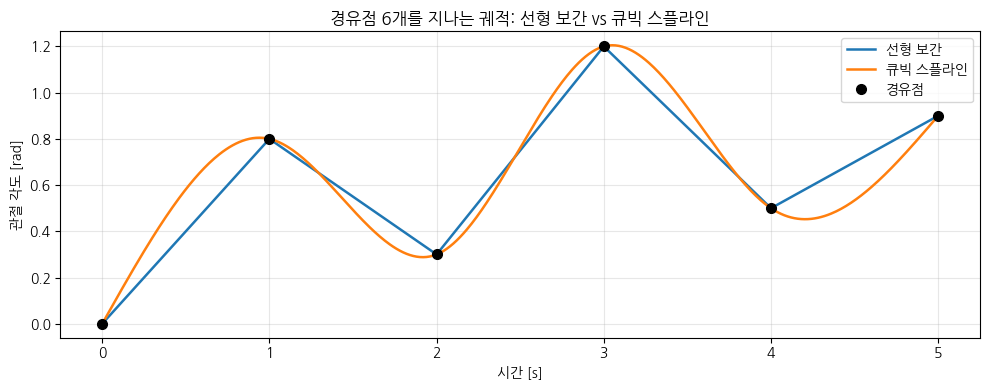

In [17]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_dense, q_lin, lw=1.8, label="선형 보간")
ax.plot(t_dense, q_spl, lw=1.8, label="큐빅 스플라인")
ax.plot(t_wp, q_wp, "ko", ms=7, label="경유점")
ax.set_xlabel("시간 [s]"); ax.set_ylabel("관절 각도 [rad]")
ax.set_title("경유점 {}개를 지나는 궤적: 선형 보간 vs 큐빅 스플라인".format(len(t_wp)))
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [18]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("shape == (501,)", q_lin.shape == t_dense.shape == q_spl.shape)
ok &= check("선형 보간이 경유점을 정확히 지난다", np.allclose(linear_interp(t_wp, q_wp, t_wp), q_wp))
ok &= check("스플라인이 경유점을 정확히 지난다", np.allclose(cubic_spline_interp(t_wp, q_wp, t_wp), q_wp))
ok &= check("두 궤적은 경유점 사이에서 다르다", np.max(np.abs(q_lin - q_spl)) > 0.01)
ok &= check("선형 보간은 경유점 사이에서 직선 (2차 차분 = 0)",
            np.allclose(np.diff(q_lin[:100], 2), 0.0))
ok &= check("스플라인은 경유점 값 범위를 크게 벗어나지 않는다", np.ptp(q_spl) < 2.0 * np.ptp(q_wp))
print("\n4-1 전체 통과:", ok)

[PASS] shape == (501,)
[PASS] 선형 보간이 경유점을 정확히 지난다
[PASS] 스플라인이 경유점을 정확히 지난다
[PASS] 두 궤적은 경유점 사이에서 다르다
[PASS] 선형 보간은 경유점 사이에서 직선 (2차 차분 = 0)
[PASS] 스플라인은 경유점 값 범위를 크게 벗어나지 않는다

4-1 전체 통과: True


## 4-2. 위치·속도·가속도 — 연속성 비교

수치 미분(`finite_diff`)으로 속도와 가속도를 구해 3단 그래프로 비교합니다.

- 선형 보간: 위치 $C^0$ — 경유점에서 **속도가 점프**하고, 가속도는 **충격(스파이크)** 이 됩니다.
- 큐빅 스플라인: $C^2$ — 속도·가속도까지 이어집니다.

연속성 지표로 **연속한 샘플 사이 최대 점프** `jump(x) = max|diff(x)|` 를 씁니다.

### 실제 로봇 관절에 어떤 차이를 만드는가

- 속도 점프가 모터·감속기에 미치는 영향: `___`
- 가속도 스파이크 = 토크 스파이크인 이유 (뉴턴 제2법칙 관점): `___`
- 그래서 어떤 방식을 관절 궤적에 쓰는가: `___`

In [19]:
def jump(x):
    """연속한 샘플 사이 최대 점프 (제공 코드)."""
    return float(np.max(np.abs(np.diff(np.asarray(x), axis=0))))

# TODO: 아래 변수를 만드세요 -> v_lin, a_lin, v_spl, a_spl   (finite_diff 두 번)
# TODO: jump(v_lin), jump(v_spl), jump(a_lin), jump(a_spl) 를 표로 출력하세요.
v_lin = finite_diff(q_lin, t_dense)
a_lin = finite_diff(v_lin, t_dense)

v_spl = finite_diff(q_spl, t_dense)
a_spl = finite_diff(v_spl, t_dense)

# jump 계산
j_v_lin = jump(v_lin)
j_v_spl = jump(v_spl)
j_a_lin = jump(a_lin)
j_a_spl = jump(a_spl)

# TODO: jump(v_lin), jump(v_spl), jump(a_lin), jump(a_spl) 를 표로 출력하세요.
print(
    f"{'Trajectory':>18} | {'jump(velocity)':>15} | {'jump(acceleration)':>20}"
)
print("-" * 60)
print(f"{'Linear Interp':>18} | {j_v_lin:15.6f} | {j_a_lin:20.6f}")
print(f"{'Cubic Spline':>18} | {j_v_spl:15.6f} | {j_a_spl:20.6f}")

        Trajectory |  jump(velocity) |   jump(acceleration)
------------------------------------------------------------
     Linear Interp |        0.800000 |            40.000000
      Cubic Spline |        0.039765 |             0.078545


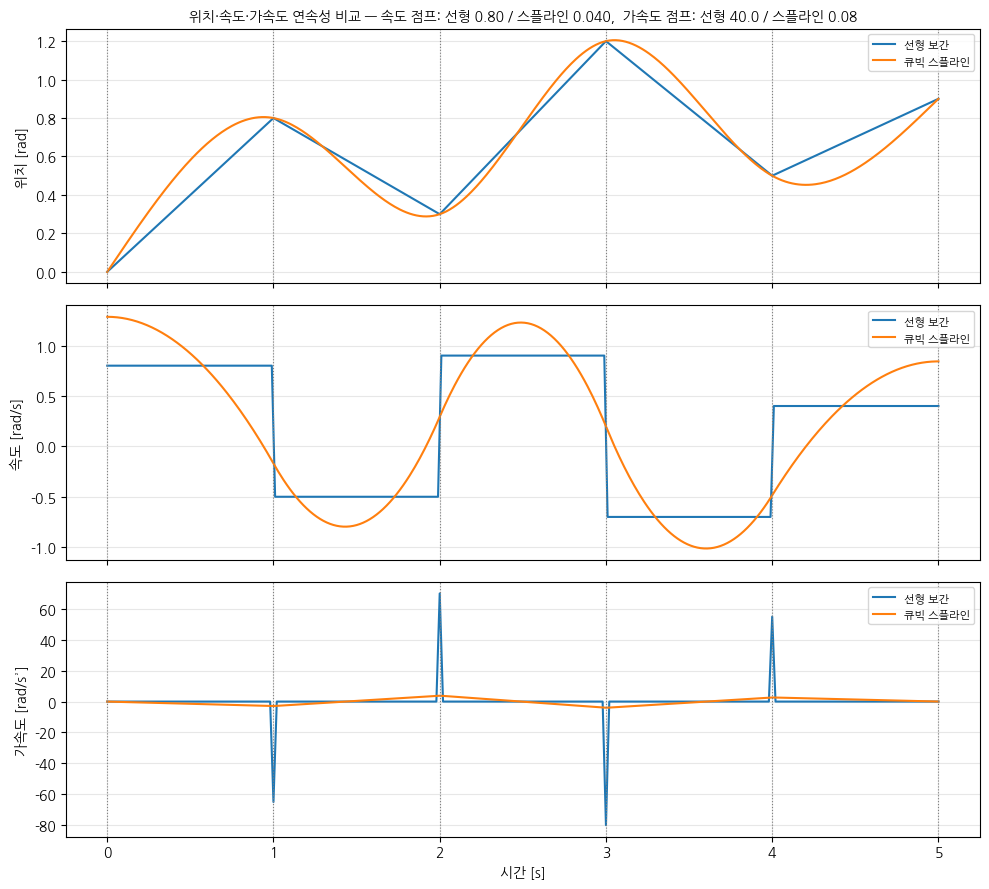

In [20]:
# --- 그래프 (제공 코드 — 그대로 쓰면 됩니다) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, (yl, ys, ylabel) in zip(axes, [
    (q_lin, q_spl, "위치 [rad]"),
    (v_lin, v_spl, "속도 [rad/s]"),
    (a_lin, a_spl, "가속도 [rad/s²]"),
]):
    ax.plot(t_dense, yl, lw=1.5, label="선형 보간")
    ax.plot(t_dense, ys, lw=1.5, label="큐빅 스플라인")
    for tw in t_wp:
        ax.axvline(tw, color="gray", ls=":", lw=0.8)
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3); ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("위치·속도·가속도 연속성 비교 — 속도 점프: 선형 {:.2f} / 스플라인 {:.3f},  가속도 점프: 선형 {:.1f} / 스플라인 {:.2f}".format(
    jump(v_lin), jump(v_spl), jump(a_lin), jump(a_spl)), fontsize=10)
axes[-1].set_xlabel("시간 [s]")
fig.tight_layout()
plt.show()

In [21]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("shape 일치", v_lin.shape == a_lin.shape == v_spl.shape == a_spl.shape == t_dense.shape)
ok &= check("선형 보간 속도는 경유점 사이에서 일정", np.allclose(v_lin[5:95], v_lin[50]))
ok &= check("선형 보간의 속도 점프가 스플라인보다 5배 이상 크다", jump(v_lin) > 5.0 * jump(v_spl))
ok &= check("선형 보간의 가속도 점프(스파이크)가 스플라인보다 5배 이상 크다", jump(a_lin) > 5.0 * jump(a_spl))
ok &= check("스플라인 속도는 연속 (점프가 속도 범위의 5% 미만)", jump(v_spl) < 0.05 * np.ptp(v_spl))
ok &= check("스플라인 가속도도 연속 (점프가 가속도 범위의 10% 미만)", jump(a_spl) < 0.10 * np.ptp(a_spl))
ok &= check("finite_diff 가 np.gradient 와 같다", np.allclose(v_spl, np.gradient(q_spl, t_dense)))
print("\n4-2 전체 통과:", ok)

[PASS] shape 일치
[PASS] 선형 보간 속도는 경유점 사이에서 일정
[PASS] 선형 보간의 속도 점프가 스플라인보다 5배 이상 크다
[PASS] 선형 보간의 가속도 점프(스파이크)가 스플라인보다 5배 이상 크다
[PASS] 스플라인 속도는 연속 (점프가 속도 범위의 5% 미만)
[PASS] 스플라인 가속도도 연속 (점프가 가속도 범위의 10% 미만)
[PASS] finite_diff 가 np.gradient 와 같다

4-2 전체 통과: True


## 4-3. 3차원 경유점 — 공간 궤적

같은 두 방식을 3차원 위치 경유점 (6,3) 에 적용합니다. `cubic_spline_interp` 는 열마다 독립적으로
보간해야 합니다 (`axis=0`). 그리퍼가 물체 위로 올라갔다 내려오는 픽앤플레이스 경로입니다.

In [22]:
# --- 3차원 경유점 (제공 코드 — tests/test_trajectory.py 와 같은 값) ---
P_wp = np.array([
    [0.20, -0.30, 0.60],
    [0.30, -0.15, 0.75],
    [0.42, 0.00, 0.80],
    [0.50, 0.15, 0.70],
    [0.55, 0.25, 0.55],
    [0.60, 0.30, 0.45],
])

# TODO: 아래 변수를 만드세요 -> P_lin, P_spl  (각각 (501,3))
P_lin = linear_interp(t_wp, P_wp, t_dense)
P_spl = cubic_spline_interp(t_wp, P_wp, t_dense)

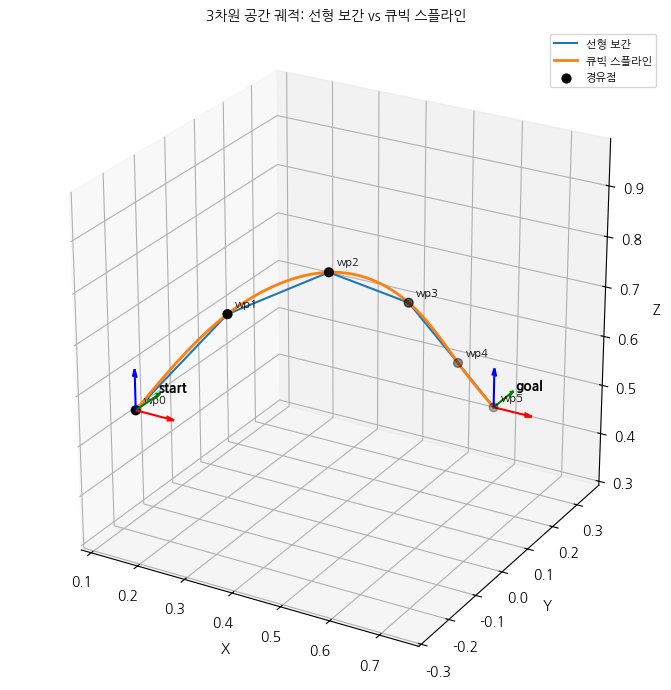

In [23]:
# --- 3D 그림 (제공 코드) ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
setup_axes(ax, "3차원 공간 궤적: 선형 보간 vs 큐빅 스플라인", lim=0.35, center=P_wp.mean(axis=0))
ax.plot(P_lin[:, 0], P_lin[:, 1], P_lin[:, 2], lw=1.5, label="선형 보간")
ax.plot(P_spl[:, 0], P_spl[:, 1], P_spl[:, 2], lw=2.0, label="큐빅 스플라인")
ax.scatter(P_wp[:, 0], P_wp[:, 1], P_wp[:, 2], color="k", s=40, label="경유점")
for i, p in enumerate(P_wp):
    ax.text(*(p + 0.01), "wp{}".format(i), fontsize=8)
draw_frame(ax, make_T(np.eye(3), P_wp[0]), scale=0.08, name="start")
draw_frame(ax, make_T(np.eye(3), P_wp[-1]), scale=0.08, name="goal")
ax.legend(fontsize=8); ax.view_init(elev=25, azim=-60)
fig.tight_layout()
plt.show()

In [24]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("shape == (501,3)", P_lin.shape == P_spl.shape == (len(t_dense), 3))
ok &= check("선형 보간이 3D 경유점을 지난다", np.allclose(linear_interp(t_wp, P_wp, t_wp), P_wp))
ok &= check("스플라인이 3D 경유점을 지난다", np.allclose(cubic_spline_interp(t_wp, P_wp, t_wp), P_wp))
ok &= check("각 열이 1차원 결과와 같다 (열 독립 보간)",
            all(np.allclose(P_spl[:, k], cubic_spline_interp(t_wp, P_wp[:, k], t_dense)) for k in range(3)))
ok &= check("스플라인 경로 길이 >= 직선 경로 길이", np.sum(np.linalg.norm(np.diff(P_spl, axis=0), axis=1))
            >= np.sum(np.linalg.norm(np.diff(P_lin, axis=0), axis=1)) - 1e-9)
print("\n4-3 전체 통과:", ok)

[PASS] shape == (501,3)
[PASS] 선형 보간이 3D 경유점을 지난다
[PASS] 스플라인이 3D 경유점을 지난다
[PASS] 각 열이 1차원 결과와 같다 (열 독립 보간)
[PASS] 스플라인 경로 길이 >= 직선 경로 길이

4-3 전체 통과: True


## 4-4. 5차 다항식 — 양끝 속도·가속도 0

경계 조건 6개 ($q, \dot q, \ddot q$ 를 양끝에서) 를 만족하려면 계수 6개, 즉 5차 다항식이 필요합니다.
양끝 속도·가속도가 0 인 기본형은

$$q(t)=q_0+(q_f-q_0)\,(10\tau^3-15\tau^4+6\tau^5),\qquad \tau=\frac{t-t_0}{t_f-t_0}$$

**할 일** — `quintic_profile` 을 구현하고 (해석적 도함수 포함) 경계 조건을 수치로 검증하세요.

### 이 조건이 왜 필요한가 (로봇 관점)

- 시작 속도가 0 이 아니면: `___`
- 시작 가속도가 0 이 아니면: `___`
- 정지 상태에서 출발해 정지 상태로 도착하는 것과 경유점 통과의 차이: `___`

In [25]:
t_q = np.linspace(0.0, 2.0, 201)

# TODO: 아래 변수를 만드세요 -> q_q, v_q, a_q, v_start, v_end, a_start, a_end
#   q_q, v_q, a_q = quintic_profile(t_q, 0.0, 2.0, 0.0, 1.0)
#   v_start, v_end = v_q[0], v_q[-1];  a_start, a_end = a_q[0], a_q[-1]
# TODO: 네 경계값과 최대 속도·최대 가속도를 출력하세요.

q_q, v_q, a_q = quintic_profile(t_q, 0.0, 2.0, 0.0, 1.0)

v_start, v_end = v_q[0], v_q[-1]
a_start, a_end = a_q[0], a_q[-1]

# 최대 속도 및 최대 가속도 (절댓값 기준)
v_max = np.max(np.abs(v_q))
a_max = np.max(np.abs(a_q))

# TODO: 네 경계값과 최대 속도·최대 가속도를 출력하세요.
print("=== 5차 다항식 프로파일 경계값 및 극댓값 ===")
print(f"시작 속도 (v_start) : {v_start:.6f}")
print(f"끝 속도   (v_end)   : {v_end:.6f}")
print(f"시작 가속도 (a_start): {a_start:.6f}")
print(f"끝 가속도   (a_end)  : {a_end:.6f}")
print(f"최대 속도   (v_max)  : {v_max:.6f}")
print(f"최대 가속도 (a_max)  : {a_max:.6f}")

=== 5차 다항식 프로파일 경계값 및 극댓값 ===
시작 속도 (v_start) : 0.000000
끝 속도   (v_end)   : 0.000000
시작 가속도 (a_start): 0.000000
끝 가속도   (a_end)  : 0.000000
최대 속도   (v_max)  : 0.937500
최대 가속도 (a_max)  : 1.443330


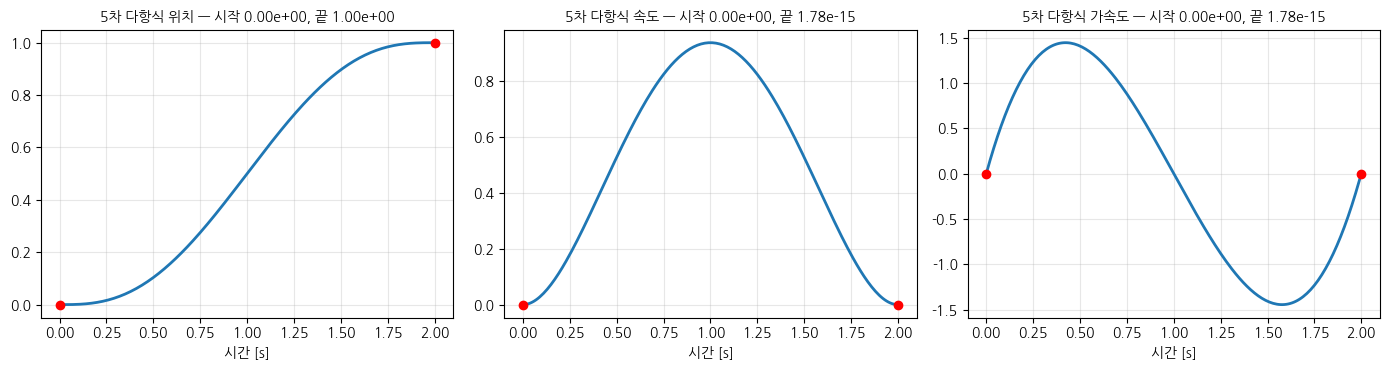

In [26]:
# --- 그래프 (제공 코드 — 그대로 쓰면 됩니다) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (y, name) in zip(axes, [(q_q, "위치"), (v_q, "속도"), (a_q, "가속도")]):
    ax.plot(t_q, y, lw=2)
    ax.scatter([t_q[0], t_q[-1]], [y[0], y[-1]], color="r", zorder=5)
    ax.set_title("5차 다항식 {} — 시작 {:.2e}, 끝 {:.2e}".format(name, y[0], y[-1]), fontsize=10)
    ax.set_xlabel("시간 [s]"); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [27]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("q(t0) == q0, q(tf) == qf", np.isclose(q_q[0], 0.0) and np.isclose(q_q[-1], 1.0))
ok &= check("시작·끝 속도 == 0", np.isclose(v_start, 0.0) and np.isclose(v_end, 0.0))
ok &= check("시작·끝 가속도 == 0", np.isclose(a_start, 0.0) and np.isclose(a_end, 0.0))
ok &= check("해석적 속도 == 수치 미분 (atol 1e-2)", np.allclose(v_q, finite_diff(q_q, t_q), atol=1e-2))
ok &= check("해석적 가속도 == 수치 미분 (atol 1e-1)", np.allclose(a_q, finite_diff(v_q, t_q), atol=1e-1))
ok &= check("최대 속도는 중간 시각", abs(t_q[int(np.argmax(v_q))] - 1.0) < 0.02)
ok &= check("최대 속도 == 1.875 * (qf - q0) / (tf - t0)", np.isclose(np.max(v_q), 1.875 * 1.0 / 2.0))
ok &= check("위치가 단조 증가", np.all(np.diff(q_q) >= -1e-12))
ok &= check("t=0.5 (tau) 에서 정확히 중간값", np.isclose(q_q[100], 0.5))
q3, v3, a3 = quintic_profile(t_q, 0.0, 2.0, np.array([0.0, 1.0, -1.0]), np.array([1.0, 0.0, 2.0]))
ok &= check("다차원 (D=3) 입력도 처리", q3.shape == (201, 3) and np.allclose(q3[-1], [1.0, 0.0, 2.0]) and np.allclose(v3[0], 0.0))
print("\n4-4 전체 통과:", ok)

[PASS] q(t0) == q0, q(tf) == qf
[PASS] 시작·끝 속도 == 0
[PASS] 시작·끝 가속도 == 0
[PASS] 해석적 속도 == 수치 미분 (atol 1e-2)
[PASS] 해석적 가속도 == 수치 미분 (atol 1e-1)
[PASS] 최대 속도는 중간 시각
[PASS] 최대 속도 == 1.875 * (qf - q0) / (tf - t0)
[PASS] 위치가 단조 증가
[PASS] t=0.5 (tau) 에서 정확히 중간값
[PASS] 다차원 (D=3) 입력도 처리

4-4 전체 통과: True


## 4-5. 보간 방식 선택 기준표

아래 표를 채우세요 (4행 필수). 선택지: 선형 / 큐빅 스플라인 / 5차 다항식 / SLERP / 기타(사유 명시).

| 용도 | 방식 | 근거 |
|---|---|---|
| 관절 궤적 (경유점 통과) | `___` | `___` |
| 자세 보간 (회전) | `___` | `___` |
| 속도 프로파일 (정지 → 정지) | `___` | `___` |
| 센서 데이터 (노이즈 낀 시계열) | `___` | `___` |

## 4-6. `tests/test_trajectory.py` — pytest

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 선형 보간이 경유점을 지나는가 | `test_linear_interp_hits_waypoints` |
| ② | 큐빅 스플라인이 경유점을 지나는가 | `test_cubic_spline_hits_waypoints` |
| ③ | 5차 다항식 양끝 속도·가속도가 0 인가 | `test_quintic_boundary_conditions` |

In [28]:
PYENV["PYTHONPATH"]=str(".")
result_t = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_trajectory.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result_t.stdout[-6000:])
print("종료 코드 :", result_t.returncode)

============================= test session starts ==============================
collecting ... collected 8 items

tests/test_trajectory.py::test_linear_interp_hits_waypoints[1d] PASSED   [ 12%]
tests/test_trajectory.py::test_linear_interp_hits_waypoints[3d] PASSED   [ 25%]
tests/test_trajectory.py::test_cubic_spline_hits_waypoints[1d] PASSED    [ 37%]
tests/test_trajectory.py::test_cubic_spline_hits_waypoints[3d] PASSED    [ 50%]
tests/test_trajectory.py::test_quintic_boundary_conditions PASSED        [ 62%]
tests/test_trajectory.py::test_spline_velocity_is_continuous PASSED      [ 75%]
tests/test_trajectory.py::test_quintic_matches_finite_difference PASSED  [ 87%]
tests/test_trajectory.py::test_quintic_is_monotonic_for_zero_boundary PASSED [100%]

============================== 8 passed in 0.26s ===============================

종료 코드 : 0


In [29]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result_t.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result_t.stdout) and ("error" not in result_t.stdout.lower()))
ok &= check("요구된 3가지 테스트가 모두 존재", all(n in result_t.stdout for n in [
    "test_linear_interp_hits_waypoints", "test_cubic_spline_hits_waypoints", "test_quintic_boundary_conditions"]))
ok &= check("통과 케이스가 3개 이상", result_t.stdout.count("PASSED") >= 3)
print("\n4-6 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 3가지 테스트가 모두 존재
[PASS] 통과 케이스가 3개 이상

4-6 전체 통과: True


## 답안 템플릿 정리

In [30]:
summary = f"""
[문제 3]
1. 행렬 -> 쿼터니언 -> 행렬 왕복 검증: 최대 오차 {roundtrip_err_max:.4e} (무작위 100개 + 특수 케이스)
2. 직접 구현 SLERP 와 SciPy 일치: 최대 오차 {slerp_err_max:.4e}
3. 중간 자세 7개 3D 그림: 위 3-3 참조 — 연속 자세 사이 각도 {float(np.mean(step_deg)):.4f} 도 (총 회전각 {angle_deg:.4f} 도)
4. 선형 보간 시 쿼터니언 크기 그래프: 위 3-4 참조 — 최대 편차: {max_norm_dev:.6f} (t = {float(ts[np.argmax(norm_dev)]):.2f})
   - 단순 선형 보간을 쓰면 안 되는 이유: 원운동도 최단 경로 등속운동하려해서 제어가 어려움
5. 경계 상황 처리 — 거의 같은 자세: NaN 없음, 시작 자세 유지 (LERP 대체) / 부호 반대: NaN 없음, R_start와 같은 회전 (최단경로 뒤집기) / 정반대 자세: NaN 없음, 모두 단위 노름·끝점 일치 (직교축 180도 경로)
6. pytest: 종료 코드 0, 통과 12 개

[문제 4]
1. 선형 보간과 스플라인 궤적 그래프: 위 4-1 참조
2. 위치·속도·가속도 비교: 속도 점프 선형 {j_v_lin:.4f} / 스플라인 {j_v_spl:.4f}, 가속도 점프 선형 {j_a_lin:.4f} / 스플라인 {j_a_spl:.4f}
   - 관찰된 연속성 차이와 로봇 관절에 미치는 영향: 선형은 C0라 경유점에서 속도 점프·가속도 스파이크가 생기고, 스플라인은 C2 연속이라 매끄러워 관절 충격이 적다
3. 3D 공간 궤적: 위 4-3 참조
4. 5차 다항식 경계 조건 — 시작 속도/가속도: {v_start:.6f} / {a_start:.6f},  끝: {v_end:.6f} / {a_end:.6f}
   - 이 조건이 필요한 이유: 정지 상태에서 출발해 정지 상태로 도착하며 출발·도착 충격과 토크 점프를 막기 위함
5. 보간 방식 선택 기준표: 위 4-5 표 참조
6. pytest: 종료 코드 {result_t.returncode}, 통과 {result_t.stdout.count('PASSED')} 개


"""
print(summary)


[문제 3]
1. 행렬 -> 쿼터니언 -> 행렬 왕복 검증: 최대 오차 1.1102e-15 (무작위 100개 + 특수 케이스)
2. 직접 구현 SLERP 와 SciPy 일치: 최대 오차 8.8818e-16
3. 중간 자세 7개 3D 그림: 위 3-3 참조 — 연속 자세 사이 각도 21.8213 도 (총 회전각 174.5701 도)
4. 선형 보간 시 쿼터니언 크기 그래프: 위 3-4 참조 — 최대 편차: 0.276340 (t = 0.50)
   - 단순 선형 보간을 쓰면 안 되는 이유: 원운동도 최단 경로 등속운동하려해서 제어가 어려움
5. 경계 상황 처리 — 거의 같은 자세: NaN 없음, 시작 자세 유지 (LERP 대체) / 부호 반대: NaN 없음, R_start와 같은 회전 (최단경로 뒤집기) / 정반대 자세: NaN 없음, 모두 단위 노름·끝점 일치 (직교축 180도 경로)
6. pytest: 종료 코드 0, 통과 12 개

[문제 4]
1. 선형 보간과 스플라인 궤적 그래프: 위 4-1 참조
2. 위치·속도·가속도 비교: 속도 점프 선형 0.8000 / 스플라인 0.0398, 가속도 점프 선형 40.0000 / 스플라인 0.0785
   - 관찰된 연속성 차이와 로봇 관절에 미치는 영향: 선형은 C0라 경유점에서 속도 점프·가속도 스파이크가 생기고, 스플라인은 C2 연속이라 매끄러워 관절 충격이 적다
3. 3D 공간 궤적: 위 4-3 참조
4. 5차 다항식 경계 조건 — 시작 속도/가속도: 0.000000 / 0.000000,  끝: 0.000000 / 0.000000
   - 이 조건이 필요한 이유: 정지 상태에서 출발해 정지 상태로 도착하며 출발·도착 충격과 토크 점프를 막기 위함
5. 보간 방식 선택 기준표: 위 4-5 표 참조
6. pytest: 종료 코드 0, 통과 8 개



